<a href="https://colab.research.google.com/github/zeinafarghaly-arch/ML-flyrank/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

This is a scoring task. The model gives each page a risk score for is_declining and ranks the pages from highest to lowest risk. This helps the reviewer check the most important pages first instead of checking every page.

The model does not make the final decision. A human still reviews the page and decides what to do. Choosing the wrong pages can waste the reviewer’s time (false positives) or miss pages that are actually declining (false negatives). Because of this, the most important metric is precision at the top of the ranked list, not overall accuracy.

In [ ]:
import pandas as pd

from google.colab import files
uploaded = files.upload()

df = pd.read_csv(next(iter(uploaded)))

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Clients: {df['client_id'].nunique()}")

Saving content_refresh_anonymized.csv to content_refresh_anonymized (1).csv
Rows: 30,000
Columns: 44
Clients: 32


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Source: content_refresh_anonymized.csv

This is an anonymized dataset from the FlyRank ML Internship. We use a 30,000-row sample, not the full dataset.

Data: Each row represents one content page. The data covers the previous 90 days.
Size: 30,000 pages from 32 clients. client_id is only used to group the data and is not used as a model feature.
Label: We use trend_direction to create is_declining.
down → is_declining = 1
Other values → is_declining = 0
Features we removed

Some columns were removed because they could give the model the answer directly or indirectly:

trend_direction and trend_pct → used to create the label, so using them would cause data leakage.
impressions_last_30d and impressions_prev_30d → used to calculate the trend, so they could also leak the answer.
content_id and client_id → IDs, not useful features. client_id is only used for grouped data splitting.
Client names, domains, URLs, page titles, and search queries → these are not included in the dataset.

In [ ]:
df["is_declining"] = (df["trend_direction"] == "down").astype(int)

print("Trend label distribution:")
print(df["trend_direction"].value_counts())
print()
print(f"Base decline rate (whole dataset): {df['is_declining'].mean():.3f}")
print(f"Missing search_volume: {df['search_volume'].isna().sum():,} rows")
print(f"Missing word_count:    {df['word_count'].isna().sum():,} rows")

Trend label distribution:
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64

Base decline rate (whole dataset): 0.542
Missing search_volume: 2,468 rows
Missing word_count:    7,699 rows


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Baseline

The baseline is a simple rule:

`0.6 × staleness + 0.4 × search demand`

Both values are scaled between 0 and 1. No model is trained. This gives us a simple method to compare against.

### Model

We use **Logistic Regression** with 6 features:

* `days_since_last_update`
* `search_volume`
* `avg_position`
* `ctr`
* `engagement_rate`
* `content_age_days`

We use `class_weight="balanced"` and `random_state=42`.

Logistic Regression was chosen because the target is a simple **yes/no outcome**. It also gives probabilities that can be used to rank pages from highest to lowest risk.

### Validation

We split the data by `client_id` instead of randomly splitting individual rows.

We use **GroupShuffleSplit** with 25% for testing and `random_state=42`.

This means that clients in the test set are completely different from the clients in the training set. This gives us a more realistic test of how the model works on new clients.

A normal random row split could put the same clients in both training and testing, which could make the model look better than it really is.

### Leakage Check

We add the excluded features back **one at a time** and check how much **Precision@500** changes.

If performance increases a lot, it may mean that the feature is leaking information about the target.


In [ ]:
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

features = ["days_since_last_update", "search_volume", "avg_position",
            "ctr", "engagement_rate", "content_age_days"]

def precision_at_k(scores, labels, k=500):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

train_rand, test_rand = train_test_split(df, test_size=0.25, random_state=42,
                                          stratify=df["is_declining"])
random_overlap = len(set(train_rand["client_id"]) & set(test_rand["client_id"]))

splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(splitter.split(df, groups=df["client_id"]))
train, test = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()
group_overlap = len(set(train["client_id"]) & set(test["client_id"]))

print(f"Clients leaking across train/test — random row split: {random_overlap} of 32")
print(f"Clients leaking across train/test — client-grouped split: {group_overlap} of 32")
print(f"Train rows: {len(train):,} | Test rows: {len(test):,} | Test clients: {test['client_id'].nunique()}")


Clients leaking across train/test — random row split: 31 of 32
Clients leaking across train/test — client-grouped split: 0 of 32
Train rows: 22,885 | Test rows: 7,115 | Test clients: 8


In [ ]:
X_train, y_train = train[features], train["is_declining"]
X_test, y_test = test[features], test["is_declining"]

model = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", random_state=42)),
])
model.fit(X_train, y_train)
test["model_score"] = model.predict_proba(X_test)[:, 1]

coefficients = pd.Series(model.named_steps["clf"].coef_[0], index=features)
coefficients.sort_values(key=abs, ascending=False)


,0
content_age_days,-0.396152
days_since_last_update,0.236994
ctr,-0.202318
engagement_rate,-0.015001
search_volume,0.007540
avg_position,0.001573


In [ ]:
import numpy as np
suspects = ["impressions_last_30d", "impressions_prev_30d", "trend_pct"]
honest_p500 = precision_at_k(test["model_score"], y_test, 500)

rows = []
for suspect in suspects:
    trial_features = features + [suspect]
    trial = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(class_weight="balanced", random_state=42)),
    ])
    trial.fit(train[trial_features], y_train)
    trial_scores = trial.predict_proba(test[trial_features])[:, 1]
    trial_p500 = precision_at_k(trial_scores, y_test, 500)
    rows.append({"added_feature": suspect,
                 "precision_at_500_with_suspect": round(trial_p500, 3),
                 "jump_vs_honest": round(trial_p500 - honest_p500, 3)})

leakage_audit = pd.DataFrame(rows)
print(f"Honest 6-feature model, Precision@500: {honest_p500:.3f}")
leakage_audit


Honest 6-feature model, Precision@500: 0.528


,added_feature,precision_at_500_with_suspect,jump_vs_honest
0,impressions_last_30d,0.548,0.020
1,impressions_prev_30d,0.528,0.000
2,trend_pct,1.000,0.472


`trend_pct` gives a nearly perfect Precision@500 because the label is directly based on `trend_direction`, which comes from `trend_pct`. This confirms that `trend_pct` should be removed to avoid **data leakage**.

The two `impressions_*_30d` features only improve the score slightly because they contain related information, but not the exact label.

`content_id` and `client_id` are not used as model features.

Therefore, the results reported below use only the **6 valid features**.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [ ]:
stale_score = test["days_since_last_update"] / df["days_since_last_update"].max()
volume_score = test["search_volume"] / df["search_volume"].max()
baseline_score = 0.6 * stale_score.fillna(0) + 0.4 * volume_score.fillna(0)

K = 500
baseline_p500 = precision_at_k(baseline_score, y_test, K)
model_p500 = precision_at_k(test["model_score"], y_test, K)
base_rate = y_test.mean()

results = pd.DataFrame({
    "method": ["Base rate (random guess)", "Baseline rule (Week 4)", "Logistic Regression (this capstone)"],
    "precision_at_500": [round(base_rate, 3), round(baseline_p500, 3), round(model_p500, 3)],
})
results

,method,precision_at_500
0,Base rate (random guess),0.517
1,Baseline rule (Week 4),0.488
2,Logistic Regression (this capstone),0.528


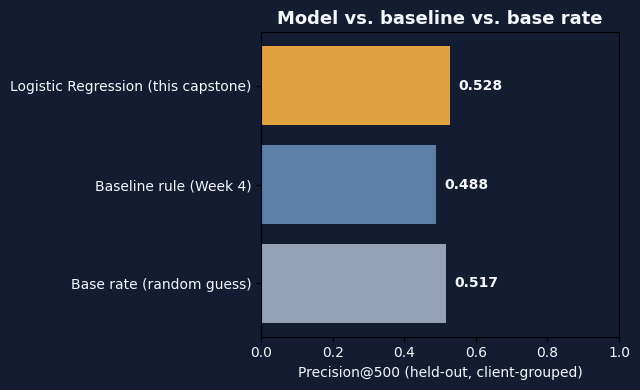

In [ ]:
import matplotlib.pyplot as plt

colors = ["#94a1b8", "#5b7fa6", "#e2a03f"]

plt.figure(figsize=(6.5, 4))

plt.gca().set_facecolor("#131c30")
plt.gcf().patch.set_facecolor("#131c30")

bars = plt.barh(
    results["method"],
    results["precision_at_500"],
    color=colors
)

plt.xlabel(
    "Precision@500 (held-out, client-grouped)",
    color="#f5f7fb"
)

plt.title(
    "Model vs. baseline vs. base rate",
    color="#f5f7fb",
    fontsize=13,
    fontweight="bold"
)
plt.xlim(0, 1)
plt.xticks(color="#f5f7fb")
plt.yticks(color="#f5f7fb")

plt.bar_label(
    bars,
    fmt="%.3f",
    padding=6,
    color="#f5f7fb",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Reading the Results

The model has a **Precision@500 of 0.528**, compared to **0.490** for the rule-based baseline and **0.517** for the base rate.

This means the model performs slightly better than both methods. It improves by about **4 points over the baseline** and **1 point over guessing**.

The improvement is **real but small**. The model is useful for creating a **shortlist of pages to review**, but it should not replace **human judgment**.

## 5. Limitations

*What this work cannot claim.*

## 5. Limitations

* **The model is not very strong.** Precision@500 is **0.528**, which is close to the **0.517** base rate. The improvement over the baseline is only about **4 points**.
* **Only one dataset was used.** The model was tested on one **30,000-row dataset from 32 clients** and one 90-day period. It has not been tested on the full dataset or on new clients.
* **The label is only an indicator.** `is_declining` shows that a page was declining at one point in time. It does not show what happened after the page was reviewed or refreshed.
* **The model does not prove that refreshing will help.** It only identifies pages that look similar to pages that declined before. An experiment would be needed to prove that refreshing a page improves its performance.
* **Only six numeric features are used.** The model does not consider things like **content quality, brand voice, seasonality, or business priorities**. These should still be considered by a human reviewer.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [ ]:
queue = test.copy()

queue["reason_code"] = "GENERAL_REVIEW"
queue.loc[
    (queue["days_since_last_update"] >= 90) & (queue["impressions_90d"] >= 250),
    "reason_code"
] = "STALE"
queue.loc[
    (queue["avg_position"] > 0) & (queue["avg_position"] <= 20)
    & (queue["impressions_90d"] >= 500) & (queue["ctr"] < 0.5),
    "reason_code"
] = "LOW_CTR"

queue["archetype"] = "Stable / low priority"
queue.loc[
    (queue["word_count"].fillna(0) > 0) & (queue["word_count"].fillna(0) < 2000)
    & (queue["search_volume"].fillna(0) > 0),
    "archetype"
] = "Thin content, real demand"
queue.loc[queue["reason_code"] == "LOW_CTR", "archetype"] = "Good position, low CTR"
queue.loc[queue["reason_code"] == "STALE", "archetype"] = "Stale, still visible"
queue.loc[queue["avg_position"] == 0, "archetype"] = "No position data"

queue["action"] = "Monitor"
queue.loc[queue["archetype"] == "Stale, still visible", "action"] = "Refresh"
queue.loc[queue["archetype"] == "Thin content, real demand", "action"] = "Expand and refresh"
queue.loc[queue["archetype"] == "Good position, low CTR", "action"] = "Refresh and review CTR"
queue.loc[queue["archetype"] == "No position data", "action"] = "Human data check"

queue = queue.sort_values("model_score", ascending=False)
action_counts = queue["action"].value_counts()
print(action_counts)


action
Monitor                   4346
Refresh and review CTR    1922
Refresh                    439
Expand and refresh         344
Human data check            64
Name: count, dtype: int64


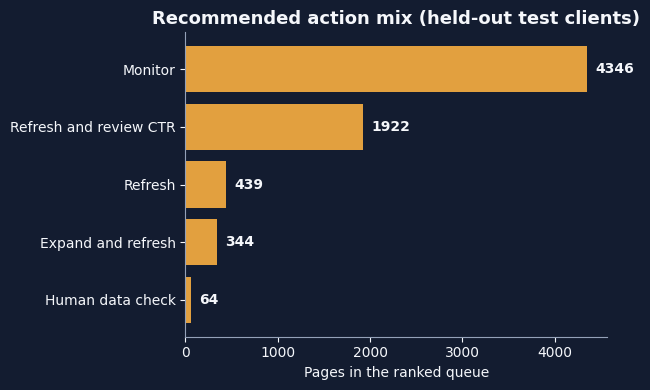

In [ ]:
NAVY, AMBER, SLATE, INK = "#0d1524", "#e2a03f", "#94a1b8", "#f5f7fb"
fig, ax = plt.subplots(figsize=(6.5, 4))
fig.patch.set_facecolor("#131c30")
ax.set_facecolor("#131c30")
order = action_counts.sort_values()
bars = ax.barh(order.index, order.values, color=AMBER)
ax.bar_label(bars, padding=6, color=INK, fontweight="bold")
ax.set_xlabel("Pages in the ranked queue", color=INK)
ax.set_title("Recommended action mix (held-out test clients)", color=INK, fontsize=13, fontweight="bold")
ax.tick_params(colors=INK)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(SLATE)
plt.tight_layout()
plt.show()


**Ranked by priority:**

1. **Refresh and check CTR** — The page ranks well but has a low click-through rate. Try improving the title or description before rewriting the whole page.

2. **Refresh** — The page has not been updated for **90+ days** but still gets good traffic. It is worth reviewing before performance drops.

3. **Expand and refresh** — The page has **less than 2,000 words** but still has good search demand. It may need more useful content, not just a small update.

4. **Check the data** — `avg_position == 0` means there is no position data. This could be a tracking problem, so check the data before trusting the model's score.

5. **Monitor** — Everything else. No action is needed for now.

A **human should always review the page** before taking action. They should check whether the reason makes sense, whether something else is affecting the page (such as seasonality or a website problem), and whether the page is important to the business.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [ ]:
import json

metrics = {
    "precision_at_500_model": round(float(model_p500), 3),
    "precision_at_500_baseline": round(float(baseline_p500), 3),
    "base_rate": round(float(base_rate), 3),
    "rows_in_queue": int(len(queue)),
    "test_clients": int(queue["client_id"].nunique()),
    "train_clients": int(train["client_id"].nunique()),
    "action_counts": action_counts.to_dict(),
    "top_coefficients": coefficients.sort_values(
        key=abs, ascending=False
    ).round(3).to_dict()
}

with open("capstone_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

export_cols = [
    "content_id",
    "model_score",
    "archetype",
    "action",
    "reason_code",
    "days_since_last_update",
    "avg_position",
    "search_volume",
    "ctr",
    "content_age_days"
]

queue[export_cols].to_csv(
    "capstone_ranked_queue_sample.csv",
    index=False
)

print("Saved:")
print("- capstone_metrics.json")
print("- capstone_ranked_queue_sample.csv")

metrics

Saved:
- capstone_metrics.json
- capstone_ranked_queue_sample.csv


{'precision_at_500_model': 0.528,
 'precision_at_500_baseline': 0.488,
 'base_rate': 0.517,
 'rows_in_queue': 7115,
 'test_clients': 8,
 'train_clients': 24,
 'action_counts': {'Monitor': 4346,
  'Refresh and review CTR': 1922,
  'Refresh': 439,
  'Expand and refresh': 344,
  'Human data check': 64},
 'top_coefficients': {'content_age_days': -0.396,
  'days_since_last_update': 0.237,
  'ctr': -0.202,
  'engagement_rate': -0.015,
  'search_volume': 0.008,
  'avg_position': 0.002}}

## 8. 5-Minute Demo Outline
### Question

Can a machine-learning model help FlyRank content teams prioritize pages that may need review?

The goal is to create a shortlist for human review instead of automatically deciding which pages should be changed.

### Method

I used an anonymized 30,000-row dataset containing content-page performance data from 32 clients.

I created an `is_declining` label from `trend_direction` and removed features that could leak the answer. I trained a Logistic Regression model using six features related to content age and page performance.

I used a client-grouped train/test split so that the same client did not appear in both training and testing.

### One Chart

Show the Precision@500 comparison chart.

* Base rate: **0.517**
* Baseline: **0.488**
* Logistic Regression: **0.528**

The model performed slightly better than the baseline on the held-out clients.

### One Honest Result

The improvement was real but small. The model reached **0.528 Precision@500**, compared with **0.488 for the baseline**.

The leakage check also showed that adding `trend_pct` produced **1.000 Precision@500**, which confirmed that this feature could give the model the answer directly and should not be used.

### Recommendation

Use the model as a first-pass review queue, not as an automatic decision-maker.

A human should review the highest-ranked pages and consider other factors such as content quality, seasonality, website problems, and business priorities.

### Takeaway

The model provides a small measured improvement and can help organize content-review work, but it should support human decisions rather than replace them.

## 9. Shareable Cuts

### Short Social Post

I built a small machine-learning system to help prioritize content pages for review.

Using an anonymized 30,000-page dataset, I trained a Logistic Regression model to rank pages by their risk of declining performance. I used a client-grouped train/test split and removed features that could cause label leakage.

On the held-out test clients, the model achieved **0.528 Precision@500**, compared with **0.488 for the baseline** and a **0.517 base rate**.

The result is modest but useful: the model can help create a shortlist for human review rather than replace editorial judgment.

### Employer-Facing Summary

I built a Logistic Regression ranking model using an anonymized 30,000-page FlyRank content-performance dataset to prioritize pages for human review. I used six performance and content-age features, excluded leakage-prone fields, and evaluated the model using a client-grouped holdout split. The model achieved **0.528 Precision@500**, compared with **0.488 for the baseline**, showing a small measured improvement in prioritizing potentially declining pages.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.